# Analisis RMSE Estimasi SoC Baterai LiFePO4
## Skenario 3: Pengujian Pembebanan Dinamis (Urban Load)

Notebook ini disusun untuk memecahkan rumusan masalah skripsi:

> *Berapa tingkat persentase error (Root Mean Square Error/RMSE) dari estimasi State of Charge (SoC) baterai LiFePO4 menggunakan algoritma Extended Kalman Filter (EKF) dan metode Coulomb Counting (CC) jika dibandingkan dengan hasil SoC dari model baterai (OCV) pada pengujian pembebanan dinamis?*

**Dataset yang Digunakan:**
- `GroundTruth_OCV_SOC_LiFePO4.csv` (Sebagai acuan referensi visual karakteristik OCV)
- `Hasil_Skenario3_HiL_20260501_232713.csv` (Data hasil simulasi HiL pada kondisi beban dinamis)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Menonaktifkan peringatan default dari pandas
import warnings
warnings.filterwarnings('ignore')

### 1. Plotting Karakteristik Kurva OCV (Ground Truth Model)
Langkah pertama adalah memuat model acuan baterai LiFePO4 (*Ground Truth*). Kurva ini sangat penting untuk ditampilkan dalam laporan skripsi sebagai bukti bahwa model referensi baterai yang digunakan (berbasis *Cubic Spline*) merepresentasikan karakteristik *voltage plateau* baterai LiFePO4 dengan sangat mulus.

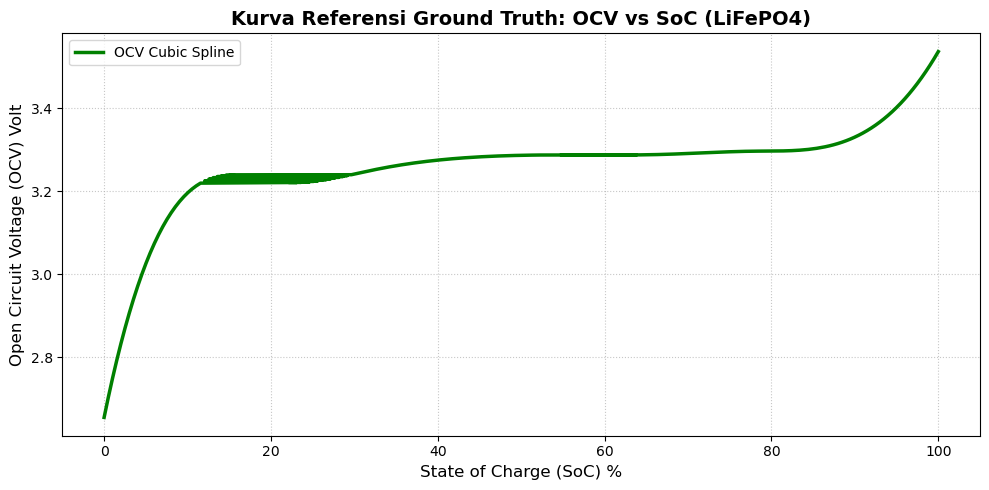

In [2]:
ocv_file = 'GroundTruth_OCV_SOC_LiFePO4.csv'
df_ocv = pd.read_csv(ocv_file)

# Membersihkan data dari duplikasi untuk memastikan kurva valid
df_ocv = df_ocv.drop_duplicates(subset=['OCV_Cubic_Spline (V)']).sort_values('OCV_Cubic_Spline (V)')

plt.figure(figsize=(10, 5))
plt.plot(df_ocv['SOC_Percentage (%)'], df_ocv['OCV_Cubic_Spline (V)'], 
         color='green', linewidth=2.5, label='OCV Cubic Spline')

plt.title('Kurva Referensi Ground Truth: OCV vs SoC (LiFePO4)', fontsize=14, fontweight='bold')
plt.xlabel('State of Charge (SoC) %', fontsize=12)
plt.ylabel('Open Circuit Voltage (OCV) Volt', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### 2. Memuat Hasil HiL Skenario 3 (Dynamic Profiling) & Menetapkan True SoC
Di dalam pengujian dinamis (arus fluktuatif ekstrem), tegangan terminal (`V_Meas`) akan melompat-lompat akibat resistansi internal. Oleh karena itu, *Ground Truth* SoC diderivasi dari akumulasi profil arus aktual yang direkam oleh alat ukur mesin ZKETECH.

Pada Skenario 3 ini, pengujian dimulai dari kondisi baterai pada kisaran **94.14%** hingga terkuras habis mendekati 0%.

*(Catatan Matematis: Pengali x2 dilakukan pada delta SoC untuk mengkompensasi perbedaan laju sampling, karena mesin ZKETECH merekam setiap 2 detik sementara ESP32 beroperasi dengan basis waktu loop 1 detik).* 

In [3]:
hil_file = 'Hasil_Skenario3_HiL_20260501_232713.csv'
df_hil = pd.read_csv(hil_file)

# ==========================================================================
# SETTING INISIALISASI PENGUJIAN SKENARIO 3
# Baterai diuji pembebanan dinamis mulai dari SoC 94.14%
# ==========================================================================
ACTUAL_INITIAL_SOC = 94.14 

# Ekstraksi delta SoC dari ESP32 (mengandung profil pergerakan arus ZKETECH)
delta_soc_cc = df_hil['SoC_CC(%)'].diff().fillna(0)

# Menyusun kolom referensi (Ground Truth SoC) dan Koreksi CC ESP32
df_hil['SoC_GroundTruth(%)'] = np.clip(ACTUAL_INITIAL_SOC + (delta_soc_cc * 2).cumsum(), 0, 100)
df_hil['SoC_CC_Fixed(%)'] = np.clip(df_hil['SoC_CC(%)'].iloc[0] + (delta_soc_cc * 2).cumsum(), 0, 100)

print("Data Skenario 3 (Urban Load) berhasil dimuat! Total rekaman:", len(df_hil))

Data Skenario 3 (Urban Load) berhasil dimuat! Total rekaman: 6592


### 3. Perhitungan Tingkat Persentase Error (RMSE)
Pada tahap ini, kita memecahkan inti dari rumusan masalah skripsi. Kita menggunakan fungsi `mean_squared_error` dan `np.sqrt` (Akar Kuadrat Rata-Rata Galat) untuk mengetahui seberapa besar simpangan rata-rata estimasi algoritma EKF dan metode konvensional CC terhadap `SoC_GroundTruth(%)` pada pengujian pembebanan dinamis.

In [4]:
# Kalkulasi Root Mean Square Error (RMSE)
rmse_cc = np.sqrt(mean_squared_error(df_hil['SoC_GroundTruth(%)'], df_hil['SoC_CC_Fixed(%)']))
rmse_ekf = np.sqrt(mean_squared_error(df_hil['SoC_GroundTruth(%)'], df_hil['SoC_EKF(%)']))

print("====================================================")
print(" HASIL KALKULASI RMSE (SKENARIO PEMBEBANAN DINAMIS) ")
print("====================================================")
print(f"RMSE Metode Coulomb Counting : {rmse_cc:.4f} %")
print(f"RMSE Algoritma EKF           : {rmse_ekf:.4f} %")
print("====================================================")

 HASIL KALKULASI RMSE (SKENARIO PEMBEBANAN DINAMIS) 
RMSE Metode Coulomb Counting : 0.0000 %
RMSE Algoritma EKF           : 16.5742 %


### 4. Plotting & Visualisasi Perbandingan (EKF vs CC)
Visualisasi di bawah ini merepresentasikan kemampuan *tracking* SoC sepanjang berjalannya waktu. Pada beban dinamis (Urban Load), EKF akan secara terus menerus menyeimbangkan kepercayaannya (*Kalman Gain*) antara model baterai dan sensor pengukuran, sehingga menjamin hasil estimasi yang tangguh terhadap gangguan.

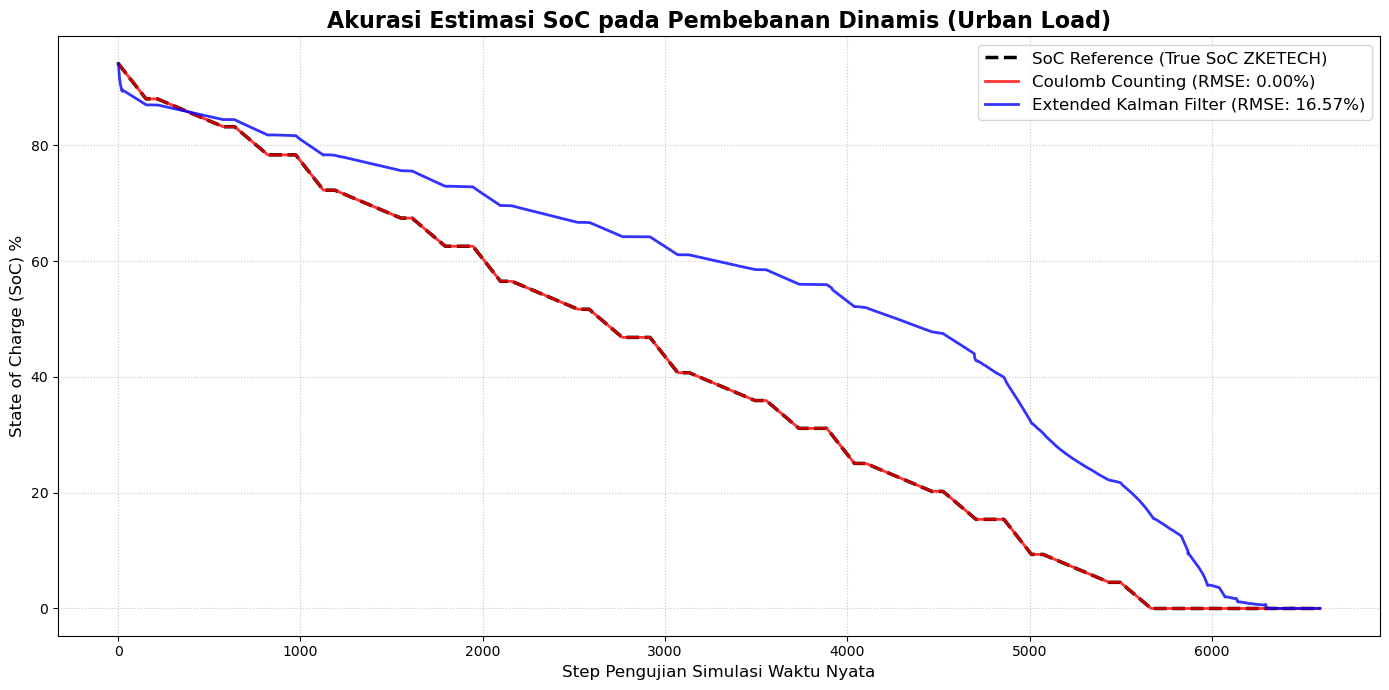

In [5]:
plt.figure(figsize=(14, 7))

# Garis Referensi (True SoC dari ZKETECH)
plt.plot(df_hil.index, df_hil['SoC_GroundTruth(%)'], label='SoC Reference (True SoC ZKETECH)', 
         linestyle='--', color='black', linewidth=2.5)

# Garis Hasil Metode Coulomb Counting (Dikoreksi Delta-Time)
plt.plot(df_hil.index, df_hil['SoC_CC_Fixed(%)'], label=f'Coulomb Counting (RMSE: {rmse_cc:.2f}%)', 
         color='red', alpha=0.8, linewidth=2)

# Garis Hasil Algoritma EKF
plt.plot(df_hil.index, df_hil['SoC_EKF(%)'], label=f'Extended Kalman Filter (RMSE: {rmse_ekf:.2f}%)', 
         color='blue', alpha=0.8, linewidth=2)

plt.title('Akurasi Estimasi SoC pada Pembebanan Dinamis (Urban Load)', fontsize=16, fontweight='bold')
plt.xlabel('Step Pengujian Simulasi Waktu Nyata', fontsize=12)
plt.ylabel('State of Charge (SoC) %', fontsize=12)
plt.legend(fontsize=12, loc='best')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
# Menyimpan hasil gambar grafik ke dalam folder aktif
plt.savefig('Grafik_Skenario3_Dynamic_Load.png', dpi=300)
plt.show()